<a href="https://colab.research.google.com/github/ange86rosales-oss/Angelina_Rosales/blob/main/Preentrega_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Dispositivo:", device)

Dispositivo: cpu


Importamos las librerías necesarias:

-torch: framework de Deep Learning.
-torch.nn: permite crear redes neuronales.
-torch.optim: contiene optimizadores como Adam.
-numpy: manejo de arreglos numéricos.
-random: generación de números aleatorios.

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()

X = iris.data
y = iris.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

print(X_train.shape)
print(X_val.shape)

torch.Size([120, 4])
torch.Size([30, 4])



El código carga el dataset Iris, normaliza los datos, los divide en entrenamiento y validación, convierte la información a tensores de PyTorch, define una red neuronal multicapa (MLP), la entrena mediante Forward Pass, cálculo de pérdida, Backpropagation y optimización con Adam. Finalmente, evalúa el modelo utilizando Accuracy y registra la evolución de la pérdida para verificar que el aprendizaje sea correcto.
```text
Dataset Iris
      ↓
Normalización
      ↓
Train / Validation Split
      ↓
Conversión a Tensores
      ↓
Red Neuronal (MLP)
      ↓
Forward Pass
      ↓
Cálculo de Loss
      ↓
Backward Pass
      ↓
Adam Optimizer
      ↓
Validación
      ↓
Accuracy y Loss por época

In [6]:
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(4,16),
            nn.ReLU(),
            nn.Linear(16,8),
            nn.ReLU(),
            nn.Linear(8,3)
        )

    def forward(self,x):
        return self.network(x)

model = IrisClassifier().to(device)

print(model)

IrisClassifier(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
)


Se implementó una red neuronal multicapa (MLP) utilizando PyTorch. La arquitectura recibe las cuatro características del dataset Iris y las procesa a través de dos capas ocultas de 16 y 8 neuronas, utilizando la función de activación ReLU para introducir no linealidad. Finalmente, una capa de salida de tres neuronas genera las predicciones correspondientes a las tres especies de flores presentes en el dataset.

In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [8]:
def evaluate(model, X, y):

    model.eval()

    with torch.no_grad():

        X = X.to(device)
        y = y.to(device)

        outputs = model(X)

        loss = criterion(outputs, y)

        predictions = torch.argmax(outputs, dim=1)

        accuracy = (
            (predictions == y)
            .float()
            .mean()
            .item()
        )

    return loss.item(), accuracy

La función evaluate se utiliza para medir el rendimiento del modelo sobre el conjunto de validación. Primero coloca la red en modo evaluación mediante model.eval y desactiva el cálculo de gradientes con torch.no_grad. Luego ejecuta un forward pass, calcula la pérdida utilizando la función de error definida y obtiene las predicciones mediante argmax. Finalmente calcula el Accuracy comparando las predicciones con las etiquetas reales y devuelve tanto la pérdida como la precisión obtenida.

In [9]:
epochs = 50

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(epochs):

    model.train()

    X_batch = X_train.to(device)
    y_batch = y_train.to(device)

    optimizer.zero_grad()

    outputs = model(X_batch)

    loss = criterion(outputs, y_batch)

    loss.backward()

    optimizer.step()

    predictions = torch.argmax(outputs, dim=1)

    train_acc = (
        (predictions == y_batch)
        .float()
        .mean()
        .item()
    )

    val_loss, val_acc = evaluate(
        model,
        X_val,
        y_val
    )

    train_losses.append(loss.item())
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs}"
        f" | Train Loss: {loss.item():.4f}"
        f" | Val Loss: {val_loss:.4f}"
        f" | Train Acc: {train_acc:.4f}"
        f" | Val Acc: {val_acc:.4f}"
    )

Epoch 1/50 | Train Loss: 1.0962 | Val Loss: 1.0896 | Train Acc: 0.3333 | Val Acc: 0.3333
Epoch 2/50 | Train Loss: 1.0936 | Val Loss: 1.0873 | Train Acc: 0.3333 | Val Acc: 0.3333
Epoch 3/50 | Train Loss: 1.0910 | Val Loss: 1.0851 | Train Acc: 0.3333 | Val Acc: 0.3333
Epoch 4/50 | Train Loss: 1.0885 | Val Loss: 1.0829 | Train Acc: 0.3333 | Val Acc: 0.3333
Epoch 5/50 | Train Loss: 1.0861 | Val Loss: 1.0807 | Train Acc: 0.3417 | Val Acc: 0.3333
Epoch 6/50 | Train Loss: 1.0837 | Val Loss: 1.0785 | Train Acc: 0.3500 | Val Acc: 0.3333
Epoch 7/50 | Train Loss: 1.0814 | Val Loss: 1.0764 | Train Acc: 0.3500 | Val Acc: 0.3333
Epoch 8/50 | Train Loss: 1.0790 | Val Loss: 1.0742 | Train Acc: 0.3500 | Val Acc: 0.3333
Epoch 9/50 | Train Loss: 1.0766 | Val Loss: 1.0720 | Train Acc: 0.3750 | Val Acc: 0.3333
Epoch 10/50 | Train Loss: 1.0743 | Val Loss: 1.0697 | Train Acc: 0.4083 | Val Acc: 0.3333
Epoch 11/50 | Train Loss: 1.0719 | Val Loss: 1.0675 | Train Acc: 0.4250 | Val Acc: 0.3333
Epoch 12/50 | Train

Este bloque implementa el ciclo de entrenamiento del modelo. En cada época se realiza un forward pass para obtener predicciones, se calcula la pérdida mediante CrossEntropyLoss, se ejecuta el proceso de Backpropagation utilizando loss.backward() y finalmente se actualizan los pesos con el optimizador Adam. Luego se calcula el Accuracy de entrenamiento y se evalúa el rendimiento sobre un conjunto de validación independiente. Las métricas de pérdida y precisión se almacenan para analizar la evolución del aprendizaje durante las distintas épocas.

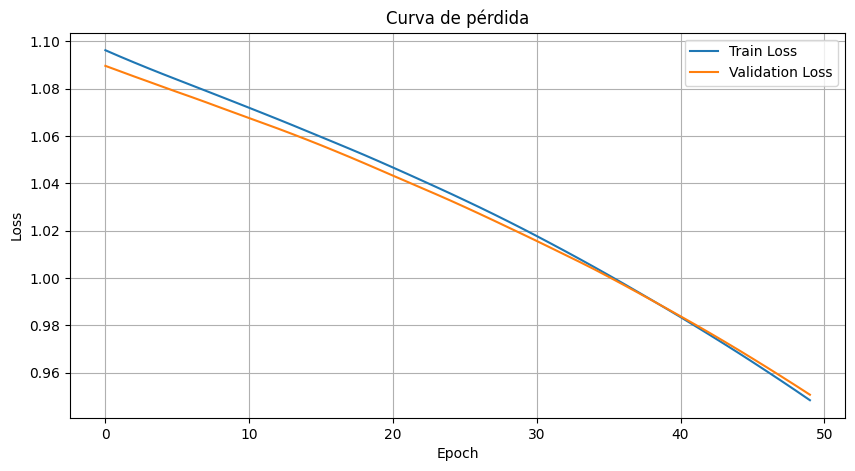

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Curva de pérdida")

plt.legend()
plt.grid(True)

plt.show()

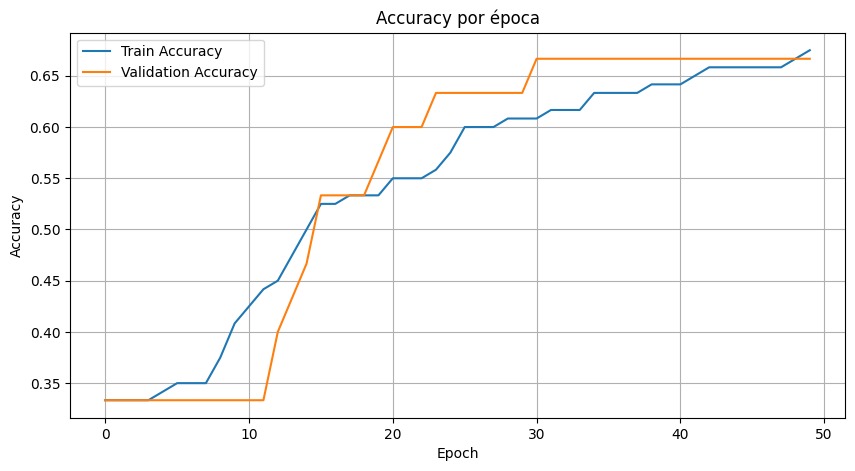

In [11]:
plt.figure(figsize=(10,5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy por época")

plt.legend()
plt.grid(True)

plt.show()